In [121]:
import numpy as np 
import cauchy_estimator as ce 
import gaussian_filters as gf
import matplotlib.pyplot as plt
#import matplotlib
#matplotlib.use('TkAgg',force=True) 

Pendulum dynamics equation
\begin{align}
\dfrac{dx_1}{dt} &= x_2 \\
\dfrac{dx_2}{dt} &= -\frac{m g l_c}{J} sin(x_1) - (\frac{B}{J} + \frac{K_m^2}{JR}) x_2
\end{align}

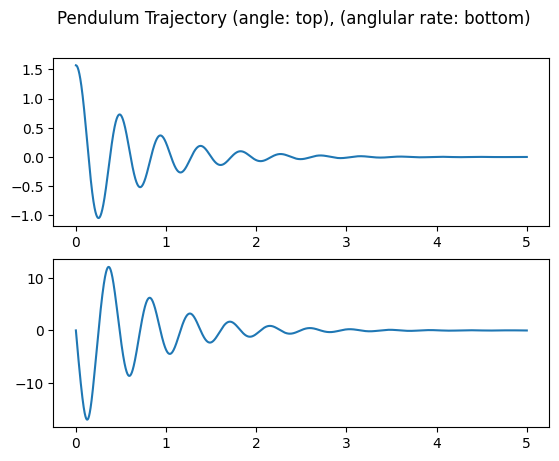

In [122]:
class PendulumParams:
    # L = 0.3 # meters
    # g = 9.81 # meters / second^2
    # c = 0.6 # 1/seconds (damping)
    # w_PSD = 0.01 # power spectral density of c-time process noise
    # dt = 0.001 # integration step time
    g = 9.81
    B = 8.1055e-6
    L = .23e-3
    R = 3.85
    V_s = 10.7
    K_m = 0.0228
    m = 0.03937
    l_c = 0.0254
    J_motor = 1.67e-6
    J_rod = 2.12e-5
    dt = 1e-3
    sr = 1000
    w_PSD = .01
    EncRes = 400
    J = 4.8270e-5
    Enc_n = 0.0157
    v_PSD = .0206
    w_PSD = 10
    H = np.array([1.0,0.0])
    Gamma_c = np.array([[0.0],[1.0]])

mp = PendulumParams() # Lets just make a simple globally viewable object to get ahold of these parameters when we want them

# The ODE
def pend_ode(x):
    dx_dt = np.zeros(2)
    dx_dt[0] = x[1]
    # dx_dt[1] = -mp.g / mp.L * np.sin(x[0]) - mp.c * x[1]
    dx_dt[1] = -(mp.B/mp.J + mp.K_m**2/(mp.J*mp.R))*x[1]-mp.m*mp.g*mp.l_c*np.sin(x[0])/mp.J
    return dx_dt 

# Nonlinear transition model from t_k to t_k+1...ie: dt
def nonlin_transition_model(x):
    return ce.runge_kutta4(pend_ode, x, mp.dt)

theta_vec0 = np.array([np.pi/2, 0]) # initial angle of 45 degrees at 0 radians/sec
theta_k = theta_vec0.copy()
thetas = [theta_k]
propagations = 5000
for k in range(propagations):
    theta_k = nonlin_transition_model(theta_k)
    thetas.append(theta_k)
thetas = np.array(thetas)
Ts = np.arange(propagations+1) * mp.dt
plt.figure()
plt.suptitle("Pendulum Trajectory (angle: top), (anglular rate: bottom)")
plt.subplot(211)
plt.plot(Ts, thetas[:, 0])
plt.subplot(212)
plt.plot(Ts, thetas[:, 1])
plt.show()

Looks like the simulation works fine. Now, lets create some angle measurements. Physically, this could be done using some sort of encoder on the rotational hinge of the pendulum, or with some type of distance sensor setup. Regardless, well observe $\theta_k$, noisily. Lets add a bit of process noise (imperfection) in its swing. For now, lets assume all noises are Gaussian. So far, our system and measurements are essentially:
\begin{align}
    x &= \begin{bmatrix}\theta\\\dot\theta\end{bmatrix}\\
    \dot{x} &= f(x) + \Gamma_c w, \quad \Gamma_c = \begin{bmatrix}0\\1\end{bmatrix}\\ 
    z_k &= [1, 0] x_k + v_k
\end{align}

/tmp/ipykernel_12602/1079059032.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  xk[1] += wk


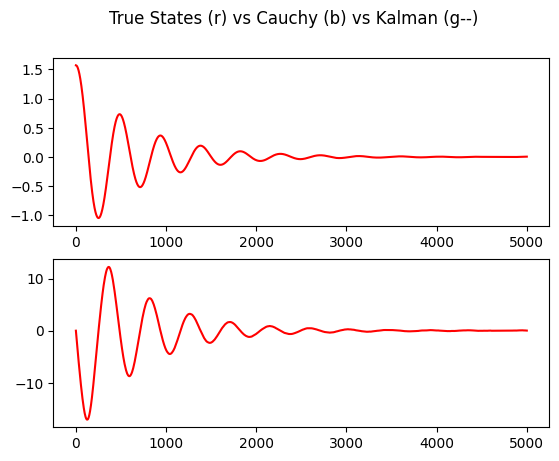

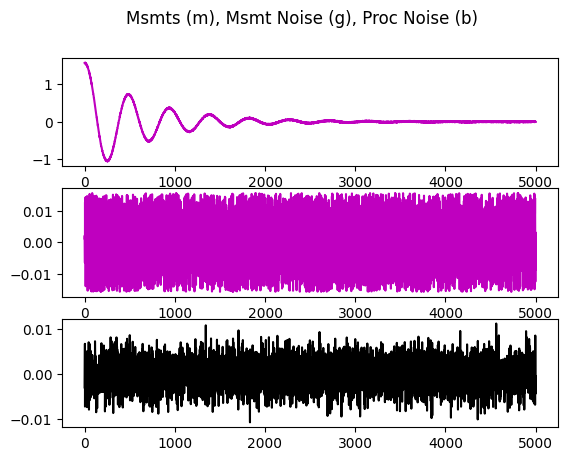

In [123]:
# Creating the dynamic simulation
# V = np.array([[0.003]]) # measurement noise on theta
# H = np.array([1.0,0.0]) # meausrement model
V = np.array([[mp.v_PSD]])
H = mp.H

xk = theta_vec0.copy()
xs = [xk] # State vector history
ws = []   # Process noise history
# vs = [V[0]**0.5 * np.random.randn()] # Measurement noise history
vs = [np.random.uniform(-mp.Enc_n,mp.Enc_n,1)]
zs = [H @ xk + vs[0]] # Measurement history
# propagations = 160
for k in range(propagations):
    wk = mp.dt * mp.w_PSD**0.5 * np.random.randn(1)
    xk[1] += wk
    xk = nonlin_transition_model(xk)
    xs.append(xk)
    ws.append(wk)
    # vk = V[0]**0.5 * np.random.randn(1)
    vk = np.array([np.random.uniform(-mp.Enc_n,mp.Enc_n)])
    zk = H @ xk + vk
    vs.append(vk)
    zs.append(zk)
xs = np.array(xs)
zs = np.array(zs)
ws = np.array(ws)
vs = np.array(vs)
ce.plot_simulation_history(None, (xs,zs,ws,vs), None)
# Now we have our simulation data!

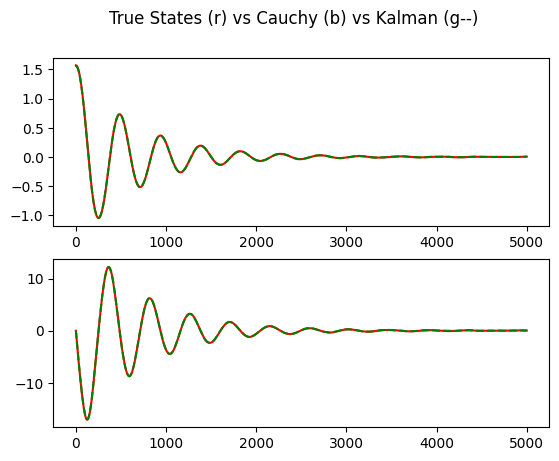

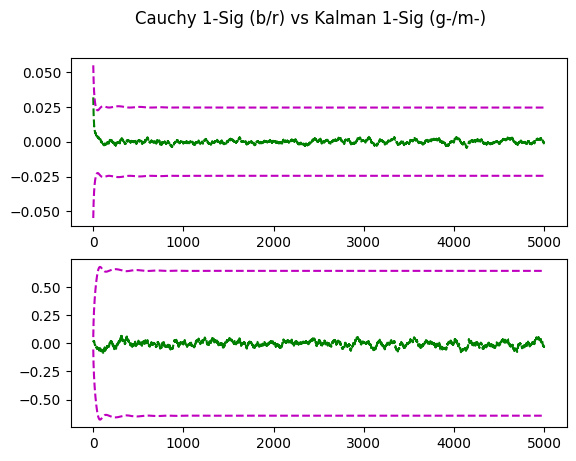

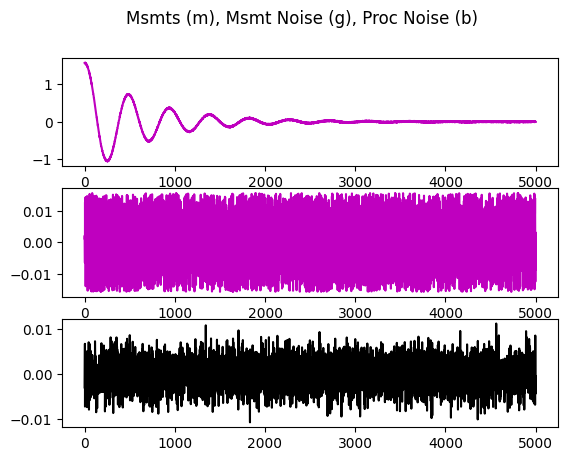

In [124]:
def jacobian_pendulum_ode(x):
    Jac = np.zeros((2,2))
    # Jac[0,1] = 1
    # Jac[1,0] = -mp.g/mp.L*np.cos(x[0])
    # Jac[1,1] = -mp.c
    Jac[0,1] = 1
    Jac[1,0] = -mp.m*mp.g*mp.l_c*np.cos(x[0])/mp.J
    Jac[1,1] = -(mp.B/mp.J + mp.K_m**2/(mp.J*mp.R))
    return Jac

# Continuous time Gamma (\Gamma_c)
# Gamma_c = np.array([[0.0,1.0]]).T
Gamma_c = mp.Gamma_c
W_c = np.array([[mp.w_PSD]])
I2 = np.eye(2)
H = H.reshape((1,2))
taylor_order = 2

# Setting up and running the EKF
# The gaussian_filters module has a "run_ekf" function baked in, but we'll just show the whole thing here
P0_kf = np.eye(2) * 0.003
x0_kf = np.random.multivariate_normal(theta_vec0, P0_kf) # lets initialize the Kalman filter slightly off from the true state position

xs_kf = [x0_kf.copy()] 
Ps_kf = [P0_kf.copy()] 
x_kf = x0_kf.copy()
P_kf = P0_kf.copy() 
for k in range(propagations):
    Jac_F = jacobian_pendulum_ode(x_kf)
    Phi_k, W_k = ce.discretize_nl_sys(Jac_F, Gamma_c, W_c, mp.dt, taylor_order, with_Gamk = False, with_Wk = True)
    # Propagate covariance and state estimates
    P_kf = Phi_k @ P_kf @ Phi_k.T + W_k
    x_kf = nonlin_transition_model(x_kf)
    # Form Kalman Gain, update estimate and covariance
    K = P_kf @ H.T @ np.linalg.inv(H @ P_kf @ H.T + V)
    zbar = H @ x_kf
    r = zs[k+1] - zbar
    x_kf += K @ r 
    P_kf = (I2 - K @ H) @ P_kf @ (I2 - K @ H).T + K @ V @ K.T
    # Store estimates
    xs_kf.append(x_kf.copy())
    Ps_kf.append(P_kf.copy())
xs_kf = np.array(xs_kf)
Ps_kf = np.array(Ps_kf)
# Plot Simulation results 
ce.plot_simulation_history( None, (xs,zs,ws,vs), (xs_kf, Ps_kf) )

In [125]:
# This is the callback function correpsonding to the decription for point 1.) above 
def foobar_dynamics_update(c_duc):
    pyduc = ce.Py_CauchyDynamicsUpdateContainer(c_duc)
    ## Propagate x 
    #x = pyduc.cget_x()
    #u = pyduc.cget_u()
    #xbar <- f(x,u)
    #pyduc.cset_x(xbar)
    #pyduc.cset_is_xbar_set_for_ece() # need to call this!
    ## Phi, Gamma, beta may update
    #pyduc.cset_Phi(Phi)
    #pyduc.cset_Gamma(Gamma)
    #pyduc.cset_beta(beta)

# This is the callback function correpsonding to the decription for point 2.) above 
def foobar_nonlinear_msmt_model(c_duc, c_zbar):
    pyduc = ce.Py_CauchyDynamicsUpdateContainer(c_duc)
    ## Set zbar
    #x = pyduc.cget_x() # xbar
    #zbar = msmt_model(x)
    #pyduc.cset_zbar(c_zbar, zbar)

# This is the callback function correpsonding to the decription for point 3.) above 
def foobar_msmt_model_jacobian(c_duc):
    pyduc = ce.Py_CauchyDynamicsUpdateContainer(c_duc)
    ## H and gamma may update
    #x = pyduc.cget_x() # xbar
    # H <- jacobian( h(x) )
    #pyduc.cset_H(H)
    #pyduc.cset_gamma(gamma)

In [126]:
# This is the callback function correpsonding to the decription for point 1.) above 
def dynamics_update(c_duc):
    pyduc = ce.Py_CauchyDynamicsUpdateContainer(c_duc)
    ## Propagate x 
    xk = pyduc.cget_x()
    xbar = nonlin_transition_model(xk) # propagate from k -> k+1
    pyduc.cset_x(xbar)
    pyduc.cset_is_xbar_set_for_ece() # need to call this!
    ## Phi, Gamma, beta may update
    Jac_F = jacobian_pendulum_ode(xk)
    Phi_k, Gam_k = ce.discretize_nl_sys(Jac_F, Gamma_c, None, mp.dt, taylor_order, with_Gamk=True, with_Wk=False)
    pyduc.cset_Phi(Phi_k)
    pyduc.cset_Gamma(Gam_k)
    #pyduc.cset_beta(beta)

# This is the callback function correpsonding to the decription for point 2.) above 
def nonlinear_msmt_model(c_duc, c_zbar):
    pyduc = ce.Py_CauchyDynamicsUpdateContainer(c_duc)
    ## Set zbar
    xbar = pyduc.cget_x() # xbar
    zbar = H @ xbar # for other systems, call your nonlinear h(x) function
    pyduc.cset_zbar(c_zbar, zbar)

# This is the callback function correpsonding to the decription for point 3.) above 
def msmt_model_jacobian(c_duc):
    pyduc = ce.Py_CauchyDynamicsUpdateContainer(c_duc)
    ## Set H: for other systems, call your nonlinear jacobian function H(x)
    pyduc.cset_H(H) # we could write some if condition to only set this once, but its such a trivial overhead, who cares

scale_g2c = 1.0 / 1.3898 # scale factor to fit the cauchy to the gaussian
beta = np.array([mp.w_PSD / mp.dt])**0.5 * scale_g2c
gamma = np.array([V[0,0]**0.5]) * scale_g2c
x0_ce = x0_kf.copy()
A0 = np.eye(2)
p0 = np.diag(P0_kf)**0.5 * scale_g2c 
b0 = np.zeros(2)
steps = 5
num_controls = 0
print_debug = True
cauchyEst = ce.PyCauchyEstimator("nonlin", steps, print_debug)
cauchyEst.initialize_nonlin(x0_ce, A0, p0, b0, beta, gamma, dynamics_update, nonlinear_msmt_model, msmt_model_jacobian, num_controls, mp.dt)
cauchyEst.step(zs[0])
cauchyEst.step(zs[1])
cauchyEst.step(zs[2])
cauchyEst.step(zs[3])
cauchyEst.step(zs[4])
cauchyEst.shutdown()

Set Cauchy Estimator Mode to: nonlin
Nonlin initialization successful! You can use the step(msmts, controls) method now to run the Cauchy Estimtor!
Note: You can call the step function 5 time-steps, 1 measurements per step == 5 total times!
Cauchy estimator backend C data structure has been shutdown!
Moment Information (after MU) at step 1, MU 1/1 (took 0 ms)
fz: 2.1174732505200984 + 0.0000000000000000j
Conditional Mean:
0.0091215646102453 + -0.0000000000000000j, 0.0000000000000000 + 0.0394101710681513j, 
Conditional Variance:
0.0042879828380837 + 0.0000000000000000j, 0.0000000000000000 + -0.0000000000000000j, 
0.0000000000000000 + -0.0000000000000000j, 0.0000000000000000 + 0.0000000000000000j, 

Moment Information (after FTR) at step 1, MU 1/1 (took 0 ms)
fz: 1.0000000000000000 + 0.0000000000000000j
Conditional Mean:
0.0091215646102453 + 0.0000000000000000j, 0.0000000000000000 + 0.0394101710681513j, 
Conditional Variance:
0.0042879828380837 + 0.0000000000000000j, 0.0000000000000000 + 

Set Sliding Window Manager Mode to: nonlin
Set Cauchy Estimator Mode to: nonlin
Set Cauchy Estimator Mode to: nonlin
Set Cauchy Estimator Mode to: nonlin
Set Cauchy Estimator Mode to: nonlin
Set Cauchy Estimator Mode to: nonlin
Set Cauchy Estimator Mode to: nonlin
Nonlin initialization successful! You can use the step(msmts, controls) method now to run the Cauchy Estimtor!
Note: You can call the step function 6 time-steps, 1 measurements per step == 6 total times!
Nonlin initialization successful! You can use the step(msmts, controls) method now to run the Cauchy Estimtor!
Note: You can call the step function 6 time-steps, 1 measurements per step == 6 total times!
Nonlin initialization successful! You can use the step(msmts, controls) method now to run the Cauchy Estimtor!
Note: You can call the step function 6 time-steps, 1 measurements per step == 6 total times!
Nonlin initialization successful! You can use the step(msmts, controls) method now to run the Cauchy Estimtor!
Note: You ca

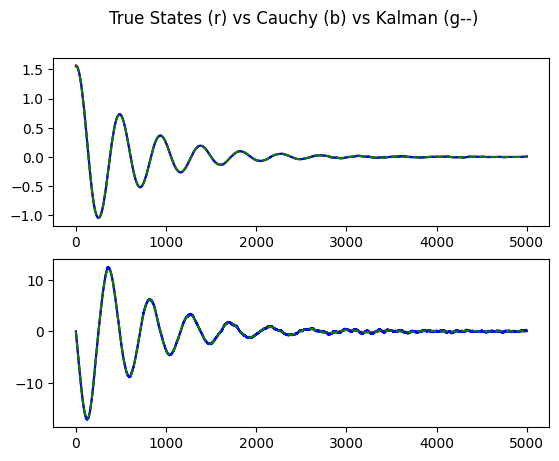

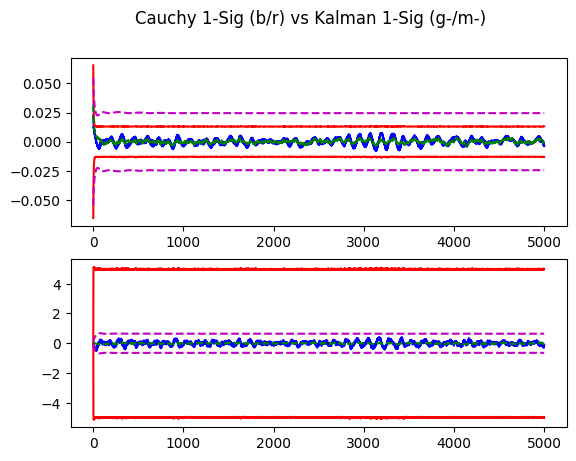

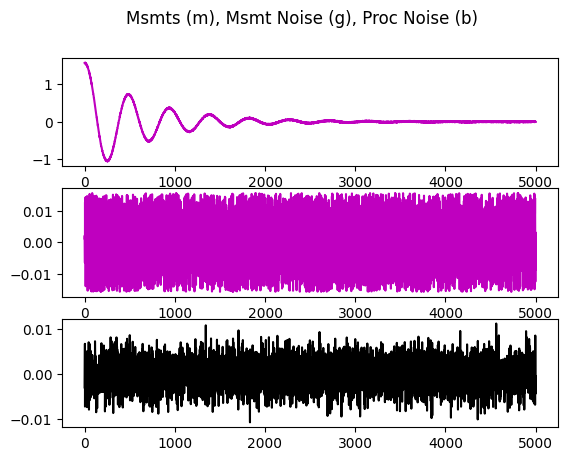

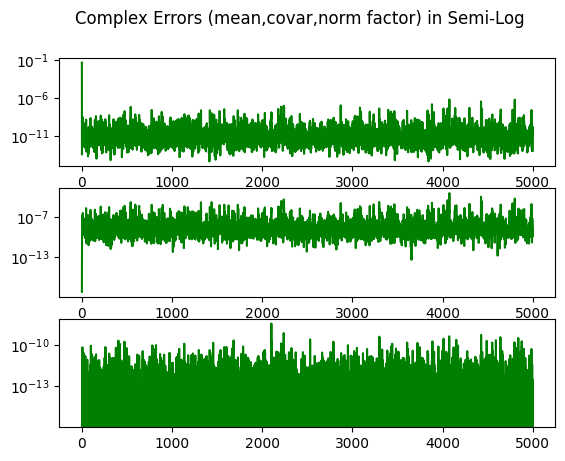

In [127]:
swm_print_debug = False 
win_print_debug = False
num_windows = 6
cauchyEst = ce.PySlidingWindowManager("nonlin", num_windows, swm_print_debug, win_print_debug)
cauchyEst.initialize_nonlin(x0_ce, A0, p0, b0, beta, gamma, dynamics_update, nonlinear_msmt_model, msmt_model_jacobian, num_controls, mp.dt)
for zk in zs:
    cauchyEst.step(zk, None)
cauchyEst.shutdown()

ce.plot_simulation_history( cauchyEst.moment_info, (xs,zs,ws,vs), (xs_kf, Ps_kf) )
#ce.plot_simulation_history( cauchyEst.avg_moment_info, (xs,zs,ws,vs), (xs_kf, Ps_kf) )

We can see that the Cauchy Estimator is a bit pessimistic in its estimates, as its 1-sigma bounds are fairly larger than the EKFs for both states. This can happen when H does not include coefficients touching all states. The estimation results are good, nevertheless, but since we are in Gaussian noise, a very simple fix is to tune the process noise statistic down slightly for the estimator, until the Cauchy 1-sigma bounds hugs that of the EKF:

Set Sliding Window Manager Mode to: nonlin
Set Cauchy Estimator Mode to: nonlin
Set Cauchy Estimator Mode to: nonlin
Set Cauchy Estimator Mode to: nonlin
Set Cauchy Estimator Mode to: nonlin
Set Cauchy Estimator Mode to: nonlin
Set Cauchy Estimator Mode to: nonlin
Nonlin initialization successful! You can use the step(msmts, controls) method now to run the Cauchy Estimtor!
Note: You can call the step function 6 time-steps, 1 measurements per step == 6 total times!
Nonlin initialization successful! You can use the step(msmts, controls) method now to run the Cauchy Estimtor!
Note: You can call the step function 6 time-steps, 1 measurements per step == 6 total times!
Nonlin initialization successful! You can use the step(msmts, controls) method now to run the Cauchy Estimtor!
Note: You can call the step function 6 time-steps, 1 measurements per step == 6 total times!
Nonlin initialization successful! You can use the step(msmts, controls) method now to run the Cauchy Estimtor!
Note: You ca

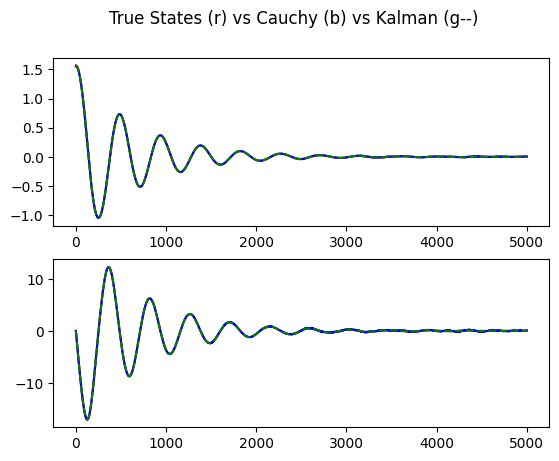

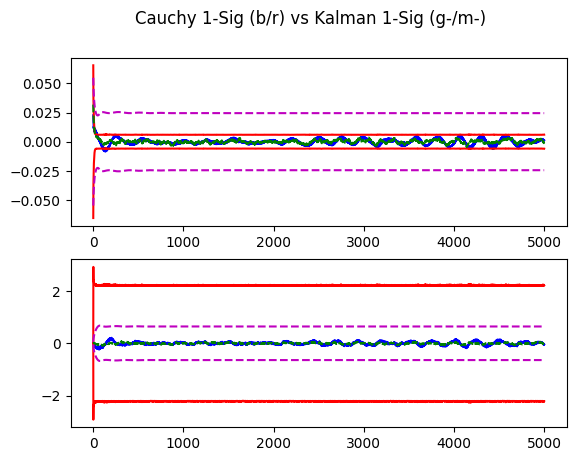

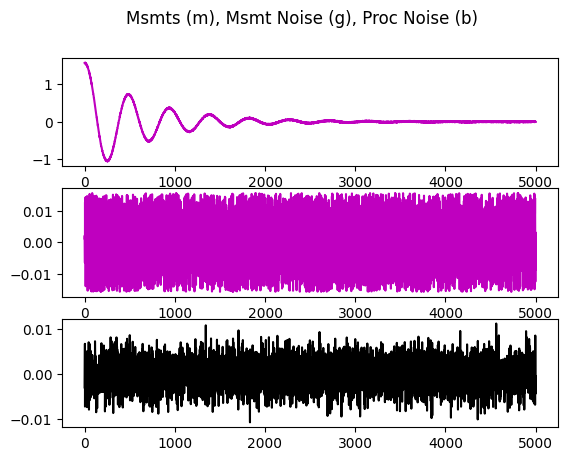

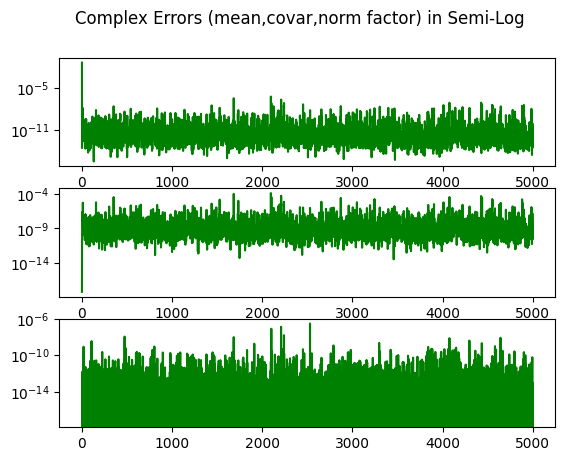

In [128]:
swm_print_debug = False 
win_print_debug = False
num_windows = 6
_beta = beta / 5 # tuned down
cauchyEst = ce.PySlidingWindowManager("nonlin", num_windows, swm_print_debug, win_print_debug)
cauchyEst.initialize_nonlin(x0_ce, A0, p0, b0, _beta, gamma, dynamics_update, nonlinear_msmt_model, msmt_model_jacobian, num_controls, mp.dt)
for zk in zs:
    cauchyEst.step(zk, None)
cauchyEst.shutdown()

ce.plot_simulation_history( cauchyEst.moment_info, (xs,zs,ws,vs), (xs_kf, Ps_kf) )
#ce.plot_simulation_history( cauchyEst.avg_moment_info, (xs,zs,ws,vs), (xs_kf, Ps_kf) )